### **Estimating Total Factor Productivity**

#### Import Libraries

In [1]:
import os 
import sys
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.stats import skew
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.formula.api import ols
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import minimize_scalar, minimize
import seaborn as sns

#### Set Up the Data

In [2]:
financial_data = pd.read_excel('Quarterly Data (with Employees).xlsx')

In [3]:
# Set up time variables
quarter_categories = list(financial_data['Fiscal Data Year and Quarter'].unique())
quarter_category_number = np.arange(len(quarter_categories)) + 1
quarter_category_number = quarter_category_number.tolist()

quarter_map = dict(zip(quarter_categories, quarter_category_number))
quarter_map[np.nan] = np.nan

financial_data['time'] = financial_data['Fiscal Data Year and Quarter'].map(quarter_map)

time_col = financial_data.pop('time')
financial_data.insert(2, 'time', time_col)

In [4]:
# Set up survival for Olley-Pakes model on original data
symbols = list(financial_data['Ticker Symbol'].unique())

dfs = {}
for symbol in symbols:
    dfs[symbol] = financial_data[financial_data['Ticker Symbol'] == symbol].copy()

for symbol, df in dfs.items():
    if dfs[symbol]['time'].iloc[-1] != 64.0:
        dfs[symbol].loc[dfs[symbol].index[-1], 'Survival'] = 0

financial_data = pd.DataFrame()

for df in dfs.values():
    financial_data = pd.concat([financial_data, df])

financial_data = financial_data.fillna(1.0)

# Set up value-added for Olley-Pakes model on original data
financial_data['val_added'] = financial_data['Revenue - Total'] - financial_data['Cost of Goods Sold']

In [5]:
# Set Up Production Function Variables
identifiers = ['Ticker Symbol',
               'time', 
               'Date']

output = ['Revenue - Total', 'val_added']

physical_capital = ['Property, Plant and Equipment - Total (Gross)',
                    'Inventories - Total',
                    'Working Capital (Balance Sheet)']

non_physical_capital = ['Research and Development Expense',
                        'Intangible Assets - Total']

depreciation_cols = ['Depreciation, Depletion and Amortization (Accumulated)',
                     'Depreciation and Amortization']

labor = ['Employees_pred_point']

additional_input_variable = ['Inventory - Raw Materials', 'Cost of Goods Sold']

survival = ['Survival']

cols = identifiers + output + physical_capital + non_physical_capital + depreciation_cols + labor + additional_input_variable + survival

financial_data = financial_data[cols]

financial_data['Physical Capital'] = financial_data[physical_capital].sum(axis=1)
financial_data['Non-Physical Capital'] = financial_data[non_physical_capital].sum(axis=1)
financial_data['PC & NPC'] = financial_data['Physical Capital'] + financial_data['Non-Physical Capital']

In [6]:
financial_data = financial_data.rename(columns={'Employees_pred_point': 'Total Employment'})

financial_data = financial_data[financial_data['Total Employment'].notna()]
financial_data = financial_data[financial_data['Depreciation, Depletion and Amortization (Accumulated)'].notna()]
financial_data['Ticker Symbol'].astype(str)

financial_data['Depreciation, Depletion and Amortization (Accumulated)'] = pd.to_numeric(
        financial_data['Depreciation, Depletion and Amortization (Accumulated)'], errors='coerce')


In [7]:
missing_values = pd.DataFrame(financial_data.isna().sum())

missing_values.rename(columns={0: 'Missing Values'}, inplace=True)
missing_values[missing_values != 0].dropna()

,Missing Values


In [8]:
financial_data = financial_data[(financial_data['Revenue - Total'] > 0)
                                & (financial_data['Cost of Goods Sold'] > 0)
                                & (financial_data['PC & NPC'] > 0)
                                & (financial_data['time'].notna())]

In [9]:
symbols = list(financial_data['Ticker Symbol'].unique())

dfs = {}
for symbol in symbols:
    dfs[symbol] = financial_data[financial_data['Ticker Symbol'] == symbol].copy()

#### *Calculate Lagged Investment*

In [10]:
target_col = 'Depreciation, Depletion and Amortization (Accumulated)'

for symbol, df in dfs.items():
    # Find the index of the first non-NaN value in the target column
    first_valid_index = df[target_col].first_valid_index()

    # If a valid index exists, trim the DataFrame starting from that row
    if first_valid_index is not None:
        dfs[symbol] = df.loc[first_valid_index:].reset_index(drop=True)

In [11]:
def reset_diff_on_drop(series):
    series = series.copy()
    # Detect where value drops (i.e., negative difference)
    drops = series.diff() < 0
    # Cumulative sum to create a group ID that resets on each drop
    group = drops.cumsum()
    # Compute the difference within each group
    return series.groupby(group).diff()

In [12]:
def capital_measures(capital_variable, measure_number, lagged_periods):
    for symbol, df in dfs.items():
        try:
            df = df.copy()

            dep_col = 'Depreciation, Depletion and Amortization (Accumulated)'
            da_total_col = 'Depreciation and Amortization'

            df[dep_col] = pd.to_numeric(df[dep_col], errors='coerce')
            df[capital_variable] = pd.to_numeric(df[capital_variable], errors='coerce')
            df[da_total_col] = pd.to_numeric(df[da_total_col], errors='coerce')

            # Depreciation Expense (reset diff on drops)
            df['Depreciation Expense'] = reset_diff_on_drop(df[dep_col])

            # Change in Gross PPE (same logic)
            df['Change in Capital'] = reset_diff_on_drop(df[capital_variable])

            # Depreciation Rate
            df['Depreciation Rate'] = df['Depreciation Expense'] / df[capital_variable]

            # Capital Expenditure
            df['Capital Expenditure'] = df['Change in Capital'] + df[da_total_col]            
            
            df = df.reset_index()
            
            for row in df['index']:
                lag = row - lagged_periods
                t_1 = row - 1
                
                # If lag is out of bounds, just use observed capital
                if lag < 0:
                    df.loc[row, f'Capital Measure {measure_number}'] = 0
                
                # If necessary components are missing, also fall back to observed capital
                elif (pd.isna(df.loc[row, 'Depreciation Expense']) or pd.isna(df.loc[row, 'Change in Capital']) or pd.isna(df.loc[lag, 'Capital Expenditure']) or pd.isna(df.loc[t_1, capital_variable])):
                    df.loc[row, f'Capital Measure {measure_number}'] = df.loc[row, capital_variable]
                
                # Otherwise, apply the recursive formula
                else:
                    df.loc[row, f'Capital Measure {measure_number}'] = ((1 - df.loc[row, 'Depreciation Rate']) * df.loc[t_1, capital_variable] + df.loc[lag, 'Capital Expenditure'])
            
            dfs[symbol] = df

        except KeyError:
            print(f"Missing required columns in {symbol}")

In [13]:
capital_measures('PC & NPC', 1, 0)
capital_measures('PC & NPC', 2, 3)

In [14]:
financial_data = pd.DataFrame()

for df in dfs.values():
    financial_data = pd.concat([financial_data, df])

financial_data.drop(columns={'index', 'level_0'}, inplace=True)

In [54]:
capital1 = financial_data[financial_data['Capital Measure 2'] > 0]
capital2 = financial_data[financial_data['Capital Measure 2'] > 0]

In [16]:
capital1 = capital1.copy()
capital2 = capital2.copy()

cols_to_log = ['Revenue - Total',
               'Cost of Goods Sold',
               'Total Employment',
               'Capital Measure 1',
               'Capital Measure 2',
               'Capital Expenditure',
               'Inventory - Raw Materials',
               'val_added']

capital1 = capital1[(capital1[cols_to_log] > 0).all(axis=1)]
capital2 = capital2[(capital2[cols_to_log] > 0).all(axis=1)]

for col in cols_to_log:
    try:
        capital1[col] = np.log(capital1[col])
        capital2[col] = np.log(capital2[col])
    except:
        continue

In [17]:
capital1[['Revenue - Total', 'Total Employment', 'Capital Measure 1']].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,6668.0,4.985635,2.301379,-5.298317,11.730453
Total Employment,6668.0,-0.790908,1.346409,-5.953021,0.865660
Capital Measure 1,6668.0,6.616594,2.361965,-1.155183,12.634399


In [18]:
capital2[['Revenue - Total', 'Total Employment', 'Capital Measure 2']].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,6668.0,4.985635,2.301379,-5.298317,11.730453
Total Employment,6668.0,-0.790908,1.346409,-5.953021,0.865660
Capital Measure 2,6668.0,6.639562,2.359365,-1.554462,12.566098


#### **Simple Linear Regression**

In [ ]:
capital1['const'] = 1
capital2['const'] = 1

capital1 = capital1.copy()
capital2 = capital2.copy()

variables_to_include_ols1 = capital1[['const',
                                      'Total Employment', 
                                      'Capital Measure 1']]
variables_to_include_ols2 = capital2[['const',
                                      'Total Employment',
                                      'Capital Measure 2']]

ols1 = sm.OLS(capital1['Revenue - Total'], variables_to_include_ols1, missing='drop').fit()
ols2 = sm.OLS(capital2['Revenue - Total'], variables_to_include_ols2, missing='drop').fit()

In [ ]:
info_dict = {'F-stat': lambda x: f"{x.fvalue:.2f}",
             'F p-value': lambda x: f"{x.f_pvalue:.3f}",
             'N Obs': lambda x: f"{int(x.nobs)}",
             'SSR': lambda x: f"{x.ssr:.2f}",
             'ESS': lambda x: f"{x.ess:.2f}",
             'MSE Res': lambda x: f"{x.mse_resid:.2f}"}

ols_results_table = summary_col(results=[ols1, ols2],
                                float_format='%0.2f',
                                stars = True,
                                model_names=['Model 1', 'Model 2'],
                                info_dict=info_dict,
                                regressor_order=['const', 
                                                 'Capital Measure 1',
                                                 'Capital Measure 2',
                                                 'Total Employment'])

ols_results_table.add_title('Table: OLS Regressions')

print(ols_results_table)

      Table: OLS Regressions
                  Model 1  Model 2 
-----------------------------------
const             2.89***  2.84*** 
                  (0.06)   (0.06)  
Capital Measure 1 0.46***          
                  (0.01)           
Capital Measure 2          0.46*** 
                           (0.01)  
Total Employment  0.90***  0.89*** 
                  (0.01)   (0.01)  
R-squared         0.96     0.96    
R-squared Adj.    0.96     0.96    
ESS               33758.18 33746.63
F p-value         0.000    0.000   
F-stat            72460.86 71901.38
MSE Res           0.23     0.23    
N Obs             6668     6668    
SSR               1552.55  1564.10 
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [22]:
intercept_reg1 = ols1.params['const']
beta_employment_reg1 = ols1.params['Total Employment']
beta_capital1_reg1 = ols1.params['Capital Measure 1']

intercept_reg2 = ols2.params['const']
beta_employment_reg2 = ols2.params['Total Employment']
beta_capital2_reg2 = ols2.params['Capital Measure 2']

In [23]:
financial_data['MPK 2'] = beta_capital2_reg2 * (financial_data['Revenue - Total'] / financial_data['Capital Measure 2'])
financial_data['MPN 2'] = beta_employment_reg1 * (financial_data['Total Employment'] / financial_data['Capital Measure 2'])

In [24]:
MPK_df = financial_data[financial_data['Capital Measure 2'] != financial_data['Capital Measure 2'].min()]

In [25]:
MPK_df[['MPK 2', 'MPN 2']].describe()

,MPK 2,MPN 2
count,17106.000000,17106.000000
mean,0.126074,0.001125
std,0.273206,0.003477
min,0.000028,0.000006
25%,0.058896,0.000298
50%,0.091080,0.000612
75%,0.138184,0.001239
max,22.113483,0.221380


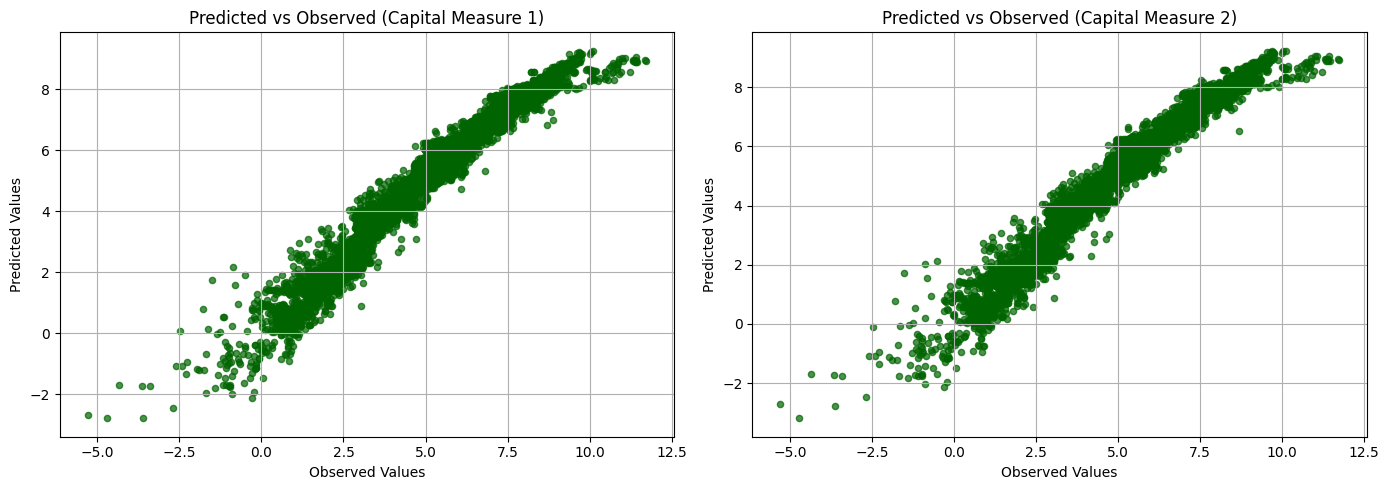

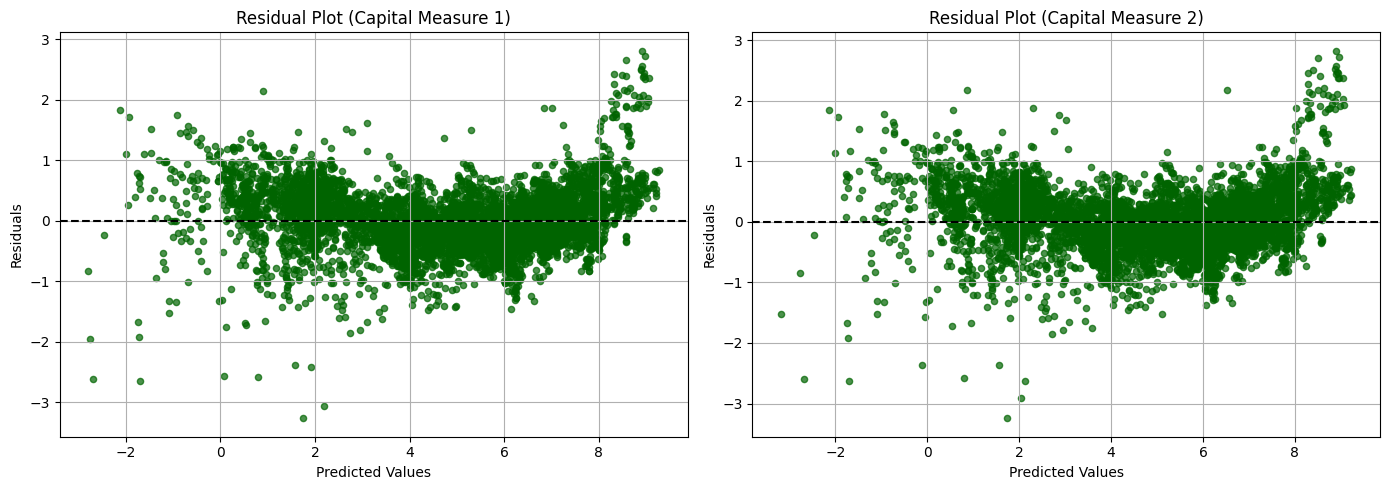

In [ ]:
y_actual1 = capital1['Revenue - Total']
y_actual2 = capital2['Revenue - Total']

pred1 = ols1.predict(variables_to_include_ols1)
pred2 = ols2.predict(variables_to_include_ols2)

# Pair actual and predicted values with model labels
actuals_preds = [(capital1['Revenue - Total'], pred1, 'Capital Measure 1'),
                 (capital2['Revenue - Total'], pred2, 'Capital Measure 2')]

# Predicted vs Observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    ax.scatter(y_actual, y_pred, alpha=0.7, s=20, color='darkgreen')
    ax.set_title(f"Predicted vs Observed ({label})")
    ax.set_xlabel("Observed Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    residuals = y_actual - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, s=20, color='darkgreen')
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_title(f"Residual Plot ({label})")
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Residuals")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### **Testing for Heteroscedasticity**

In [27]:
white_test = het_white(ols2.resid,  ols2.model.exog)
bp_test = het_breuschpagan(ols2.resid, ols2.model.exog)


In [ ]:
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_test = dict(zip(labels, bp_test))
white_test = dict(zip(labels, white_test))

test = pd.DataFrame(bp_test, white_test)
test = test.iloc[0:2, :].transpose()
test.rename(columns={'LM Statistic': 'White Test', 'LM-Test p-value': 'BP Test'})

,White Test,BP Test
LM Statistic,3.167802e+02,3.167802e+02
LM-Test p-value,1.629464e-69,1.629464e-69
F-Statistic,1.662153e+02,1.662153e+02
F-Test p-value,3.598419e-71,3.598419e-71


LM-Test p-value at 0.036 indicates that there is heteroscedasticity.

#### **Identifying Heterogeneity**

In [29]:
data = financial_data.dropna()

In [ ]:
unit = 'Ticker Symbol'
outcome = 'Revenue - Total'

group_means = data.groupby(unit)[outcome].mean()
overall_mean = data[outcome].mean()

between_var = ((group_means - overall_mean) ** 2 * data.groupby(unit).size()).sum()
within_var = data.groupby(unit).apply(
    lambda group: ((group[outcome] - group[outcome].mean()) ** 2).sum()).sum()
total_var = ((data[outcome] - overall_mean) ** 2).sum()

print(f"Between-unit variation: {between_var / total_var:.2%}")
print(f"Within-unit variation: {within_var / total_var:.2%}")

Between-unit variation: 85.11%
Within-unit variation: 14.89%


Significant between-unit variation, indicating heterogeneity across units.

### **Fixed Effects Models**

#### Capital Measure 1

In [63]:
def fixed_effects_model(df, capital_measure):
    # Step 1: Drop missing
    data = df.dropna(subset=['Ticker Symbol', 'time', 'Revenue - Total', capital_measure, 'Total Employment'])

    # Step 2: Set firm and time index
    data = data.set_index(['Ticker Symbol', 'time'])
    data['firm_id'] = data.index.get_level_values('Ticker Symbol')
    data['time_id'] = data.index.get_level_values('time')

    # Step 3: Reset index temporarily
    data_reset = data.reset_index()

    # Step 4: Create time dummies
    time_dummies = pd.get_dummies(data_reset['time'], prefix='quarter', drop_first=True)

    # Step 5: Set up X and y
    X = data_reset[[capital_measure, 'Total Employment']]
    X = sm.add_constant(X)

    y = data_reset['Revenue - Total']

    # Step 6: Set back to MultiIndex
    X.index = pd.MultiIndex.from_frame(data_reset[['Ticker Symbol', 'time']])
    y.index = pd.MultiIndex.from_frame(data_reset[['Ticker Symbol', 'time']])

    # Step 7: Set up cluster IDs
    clusters = data_reset[['firm_id', 'time_id']]
    clusters.index = X.index

    # Step 8: Run Fixed Effects model
    FE1 = PanelOLS(y, X, entity_effects=True, time_effects=True)
    FE1_results = FE1.fit(cov_type='clustered', cluster_entity=True)

    # Step 9: View results
    return FE1_results.summary

In [64]:
fixed_effects_model(capital1, 'Capital Measure 1')

Dep. Variable:,Revenue - Total,R-squared:,0.1922
Estimator:,PanelOLS,R-squared (Between):,0.4439
No. Observations:,17106,R-squared (Within):,0.2104
Date:,"Sun, Apr 05 2026",R-squared (Overall):,0.3872
Time:,15:25:40,Log-likelihood,-1.482e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1958.6
Entities:,586,P-value,0.0000
Avg Obs:,29.191,Distribution:,"F(2,16461)"
Min Obs:,1.0000,,
Max Obs:,55.000,F-statistic (robust):,18.482


In [65]:
fixed_effects_model(capital2, 'Capital Measure 2')

Dep. Variable:,Revenue - Total,R-squared:,0.1847
Estimator:,PanelOLS,R-squared (Between):,0.4395
No. Observations:,17106,R-squared (Within):,0.2025
Date:,"Sun, Apr 05 2026",R-squared (Overall):,0.3774
Time:,15:25:47,Log-likelihood,-1.483e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1864.1
Entities:,586,P-value,0.0000
Avg Obs:,29.191,Distribution:,"F(2,16461)"
Min Obs:,1.0000,,
Max Obs:,55.000,F-statistic (robust):,18.043


### **Implementing Olley-Pakes**

Olley-Pakes use the following production function:

$$ y_{it} = \beta_0 + \beta_a a_{it} + \beta_k k_{it} + \beta_l l_{it} + \omega_{it} + \nu_{it} $$

where $y_{it}$ is the log of output (value added) from plant i at time t, $a_{it}$ its age, $k_{it}$ the log of its capital input, $l_{it}$ the log of its labor input, $\omega_{it}$ its productivity, and $\nu_{it}$ is either measurement error (which can be serially correlated) or a shock to productivity which is not forecastable during the period in which labor can be adjusted. Here both $\omega$ and $\nu$ are unobserved. The distinction is that $\omega$ is a state variable in the firm's decision problem, and hence a determinant of both liquidation and input demand decisions, while $\nu$ is not.

In [33]:
df_OP = capital2[['Ticker Symbol', 
                  'time',
                  'Total Employment',
                  'Capital Measure 1',
                  'Capital Measure 2',
                  'Capital Expenditure',
                  'Revenue - Total',
                  'Cost of Goods Sold',
                  'Survival',
                  'val_added']]

capital_measure = 'Capital Measure 2'
df_OP.dropna(inplace=True)

In [34]:
symbols = list(df_OP['Ticker Symbol'].unique())

dfs = {}
for symbol in symbols:
    dfs[symbol] = df_OP[df_OP['Ticker Symbol'] == symbol].copy()

for symbol, df in dfs.items():
    df['y_next'] = df['val_added'].shift(-1)
    df['l_next'] = df['Total Employment'].shift(-1)
    df['k_next'] = df[capital_measure].shift(-1)        

    dfs[symbol] = df

df_OP = pd.DataFrame()

for df in dfs.values():
    df_OP = pd.concat([df_OP, df])


The "partially linear" model below: $$y_{it} = \beta_l l_{it} + \Phi_t(i_{it}, a_{it}, k_{it})+\Nu_{it}$$

is a semiparametric regression model (Engel, Granger, Rice, and Weiss (1986) and Robinson (1988)) which identifies $\beta_l$ but not the production function coefficients of capital and age, $\beta_a$ and $\beta_k$. That is, the equation does not allow us to separate the effect of capital and age on the investment decision from their effect on output. 

We estimate the partially linear model as follows:

In [35]:
y = 'val_added'
i = 'Capital Expenditure'
k = capital_measure
l = 'Total Employment'
t = 'time'

cols_to_check = [y, i, k, l]
df_OP = df_OP.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_to_check)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(df_OP[[i, k]])

poly_features = poly.get_feature_names_out([i, k])
X_poly_df = pd.DataFrame(X_poly, columns=poly_features, index=df_OP.index)

X_poly_df[l] = df_OP[l]
X_poly_df = pd.concat([X_poly_df], axis=1)

X = sm.add_constant(X_poly_df)
y = df_OP[y]

OP_Stage1 = sm.OLS(y, X).fit()

print(OP_Stage1.summary())

                            OLS Regression Results                            
Dep. Variable:              val_added   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     9388.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:12:54   Log-Likelihood:                -6160.4
No. Observations:                6668   AIC:                         1.234e+04
Df Residuals:                    6657   BIC:                         1.242e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

To identify $\beta_a$ and $\beta_k$ we use, in addition to the estimates of $\beta_l$ and $\Phi_t(\cdot)$ obtained from the partially linear model, estimates of the survival probabilities. These probabilities are given by: 

$$
\begin{aligned}
\quad \text{Pr} \{ \chi_{t+1} = 1 &| \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), J_t \} \\
&= \text{Pr} \{ \omega_{t+1} \geq \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}) | \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t \{ \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t (i_t, a_t, k_t) \\
&\equiv P_t
\end{aligned}
$$

In [ ]:
beta_l = OP_Stage1.params['Total Employment']
df_OP['phi_hat'] = OP_Stage1.predict(X)

X_probit = X_poly_df.drop(columns=['Total Employment']) 
X_probit = sm.add_constant(X_probit)

# Estimate Probit (Survival on Poly(i, k))
OP_probit_model = sm.Probit(df_OP['Survival'], X_probit).fit() # Use X_probit here

# Predict survival probabilities
df_OP['survival_prob'] = OP_probit_model.predict(X_probit)

Optimization terminated successfully.
         Current function value: 0.113224
         Iterations 8


In [37]:
OP_probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:               Survival   No. Observations:                 6668
Model:                         Probit   Df Residuals:                     6658
Method:                           MLE   Df Model:                            9
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                 0.03738
Time:                        15:12:54   Log-Likelihood:                -754.98
converged:                       True   LL-Null:                       -784.29
Covariance Type:            nonrobust   LLR p-value:                 2.457e-09
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                       1.3581      0.299      4.539      0.000       0.772       1.944
Capital Expenditure                        -0.1954      0.270     -0.723      0.470      -0.725       0.334
Capital Measure 2                           0.3030      0.278      1.089      0.276      -0.242       0.848
Capital Expenditure^2                       0.1975      0.096      2.065      0.039       0.010       0.385
Capital Expenditure Capital Measure 2      -0.2547      0.194     -1.314      0.189      -0.635       0.125
Capital Measure 2^2                         0.0627      0.103      0.608      0.543      -0.139       0.265
Capital Expenditure^3                       0.0235      0.011      2.136      0.033       0.002       0.045
Capital Expenditure^2 Capital Measure 2    -0.0735      0.033     -2.203      0.028      -0.139      -0.008
Capital Expenditure Capital Measure 2^2     0.0655      0.035      1.889      0.059      -0.002       0.133
Capital Measure 2^3                        -0.0171      0.012     -1.385      0.166      -0.041       0.007
===========================================================================================================
"""

The third (and final) step of the estimation procedure takes the estimates of $\beta_l$, $\phi_t$, and $P_t$ from the first two steps, substitutes them into equation (12) for the true $\beta_l$, $\phi_t$, and $P_t$, and then obtains estimates of $(\beta_a, \beta_k)$, by minimizing the sum of squared residuals in that equation. Here we try both a series and a kernel estimator of the unknown $g(P_t, h_t)$ function. Recall that we estimate $\phi_t$ and $h_t = \phi_t - \beta_a a_t - \beta_k k_t$, so the values of the regressors that determine $g(\cdot)$ depend upon the values of the parameters of interest.

For the series estimator we used a fourth order polynomial expansion in $(P_t, h_t)$ (and again there was almost no difference in either the sum of squares, or in the coefficients of interest, between the third and the fourth order approximation). Thus the series estimator is obtained by running nonlinear least squares on the equation

$$
\quad y_{t+1} - b_l l_{t+1} = c + \beta_a a_{t+1} + \beta_k k_{t+1} + \sum_{j=0}^{4-m} \sum_{m=0}^{4} \beta_{mj} \hat{h}_t^m \hat{P}_t^j + e_t
$$

with 

$$
\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t.
$$

Here $\hat{\phi}_t$ and $b_l$ are taken from the estimates of the partially linear model in (8), and $\hat{P}_t$ is taken from the kernel estimates of the survival probability in (10).

The kernel estimator is obtained by forming a kernel estimator of the regression of 

$$
y_{t+1} - b_l l_{t+1} - \beta_a a_{t+1} - \beta_k k_{t+1}
$$

on $\hat{P}_t$ and $\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t$, for different values of $(\beta_a, \beta_k)$, and then using a nonlinear search routine to find that value of $(\beta_a, \beta_k)$ that minimized the sum of squared residuals from this regression. Again the results are the bias reducing kernels in Bierens (1987) (though we also used a standard normal kernel with little difference in the resulting coefficient estimates).$^{23}$

In [ ]:
df_2nd = df_OP.dropna(subset=['y_next', 'k_next', 'l_next', 
                              'phi_hat', 'survival_prob', capital_measure]).copy()

Y_next = df_2nd['y_next']
L_next = df_2nd['l_next']
K_next = df_2nd['k_next']
K_curr = df_2nd[capital_measure]
Phi_hat = df_2nd['phi_hat']
P_hat = df_2nd['survival_prob']
beta_l_hat = beta_l # From Stage 1

def nlls_objective(params):
    beta_k_guess = params
    lhs = Y_next - (beta_l_hat * L_next)
    h_hat = Phi_hat - (beta_k_guess * K_curr)
    # polynomial in (P_hat, h_hat)
    X_g = np.column_stack((P_hat, h_hat))
    poly = PolynomialFeatures(degree=4, include_bias=True)
    X_poly = poly.fit_transform(X_g)
    target = lhs - (beta_k_guess * K_next)
    model = sm.OLS(target, X_poly).fit()
    return model.ssr

# Assume beta_k is likely between 0 and 1 for stability
result = minimize_scalar(nlls_objective, bounds=(0.0, 1.0), method='bounded')

beta_k_final = result.x
print(f"Estimated Beta_K: {beta_k_final}")

# Update dataframe with final TFP
df_OP['TFP_OP'] = np.exp(df_OP['val_added'] - 
                        (beta_l_hat * df_OP['Total Employment']) - 
                        (beta_k_final * df_OP[capital_measure]))

Estimated Beta_K: 0.37047670583516507


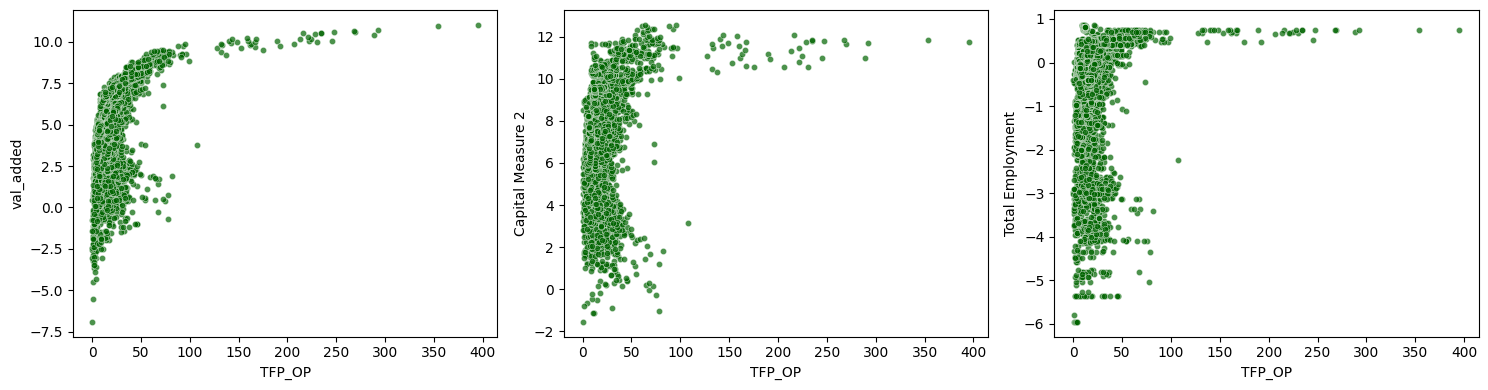

In [ ]:
pair_plot_df = df_OP[['val_added',
                      'Capital Measure 2',
                      'Total Employment',
                      'TFP_OP']]

pair_plot_df = pair_plot_df.reset_index()
pair_plot_df.drop(columns={'index'}, inplace=True)

main_var = 'TFP_OP'
other_vars = [col for col in pair_plot_df.columns if col != main_var]

fig, axes = plt.subplots(1, len(other_vars), figsize=(5 * len(other_vars), 4))
if len(other_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, other_vars):
    
    sns.scatterplot(x=pair_plot_df[main_var], y=pair_plot_df[var], alpha=0.7, s=20, color='darkgreen', ax=ax)
    ax.set_xlabel(main_var)
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

In [40]:
df_OP.dropna(subset='time', inplace=True)

In [ ]:
inv_quarter_map = {v: k for k, v in quarter_map.items()}

# Map the 'time' column to actual quarter-year labels
df_OP['quarter_label'] = df_OP['time'].map(inv_quarter_map)

# Split into year and quarter
df_OP['quarter'] = df_OP['quarter_label'].str[-1].astype(int)
df_OP['year'] = df_OP['quarter_label'].str[:4].astype(int)

In [ ]:
# Prepare data for decomposition
OP_decomp = df_OP.dropna(subset=['TFP_OP', 'val_added', 'year']).copy()

# 1. Calculate log productivity (p) and shares (s)
OP_decomp['p_it'] = np.log(OP_decomp['TFP_OP'])

# Calculate Industry Share s_it
OP_decomp['year_total_rev'] = OP_decomp.groupby('year')['val_added'].transform('sum')
OP_decomp['s_it'] = OP_decomp['val_added'] / OP_decomp['year_total_rev']

# 2. Calculate Unweighted Mean Productivity (p_bar_t)
p_bar_t = OP_decomp.groupby('year')['p_it'].mean().rename('unweighted_mean_p')

# 3. Calculate the Cross-Sectional Covariance term
weighted_avg_p = OP_decomp.groupby('year').apply(
    lambda x: np.sum(x['s_it'] * x['p_it'])).rename('weighted_mean_p')

decomposition_df = pd.concat([p_bar_t, weighted_avg_p], axis=1)
decomposition_df['covariance_term'] = decomposition_df['weighted_mean_p'] - decomposition_df['unweighted_mean_p']
print(decomposition_df.head())

      unweighted_mean_p  weighted_mean_p  covariance_term
year                                                     
2011           2.749499         2.918211         0.168712
2012           2.638544         2.849328         0.210784
2013           2.686198         2.842434         0.156236
2014           2.652986         2.805123         0.152137
2015           2.601471         2.808038         0.206568


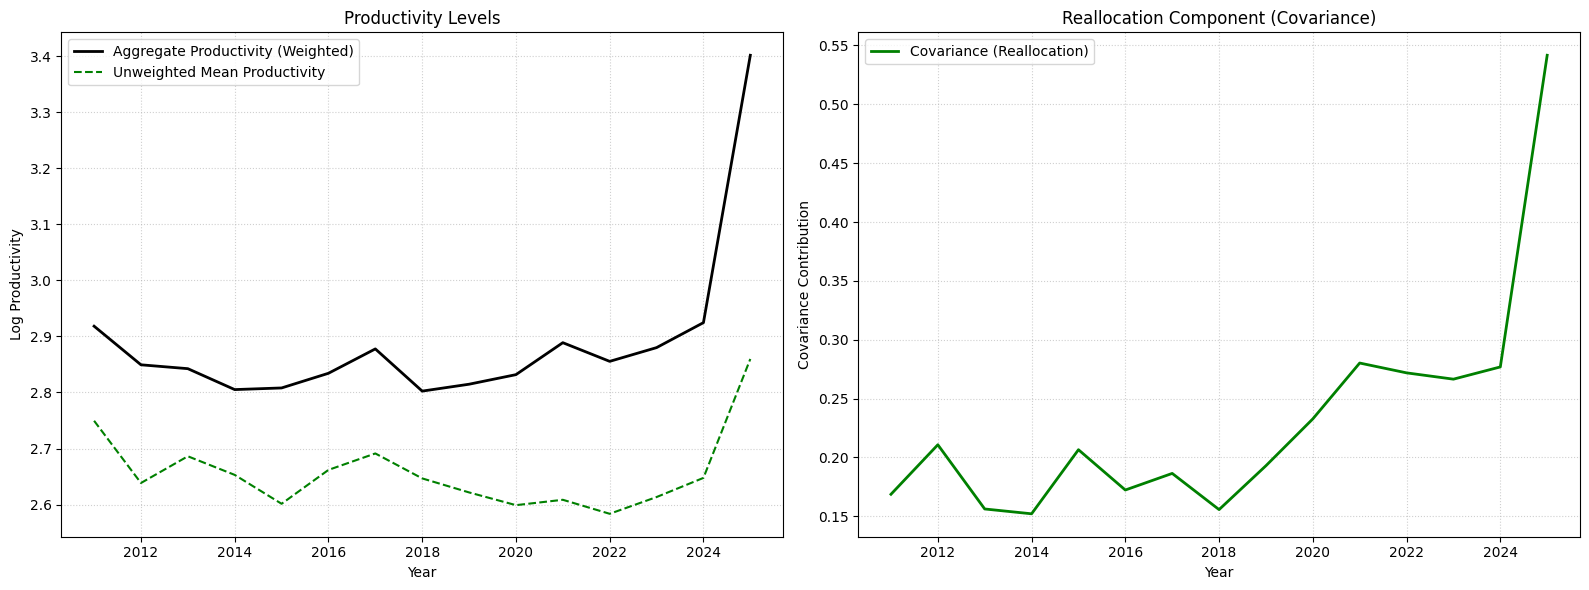

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(decomposition_df.index, decomposition_df['weighted_mean_p'], 
         label='Aggregate Productivity (Weighted)', linewidth=2, color='black')
ax1.plot(decomposition_df.index, decomposition_df['unweighted_mean_p'], 
         label='Unweighted Mean Productivity', linestyle='--', color='green')

ax1.set_title('Productivity Levels')
ax1.set_xlabel('Year')
ax1.set_ylabel('Log Productivity')
ax1.legend(loc='best')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(decomposition_df.index, decomposition_df['covariance_term'], 
         label='Covariance (Reallocation)', color='green', linewidth=2)

ax2.set_title('Reallocation Component (Covariance)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Covariance Contribution')
ax2.legend(loc='best')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Prepare Data for Robustness Test
df_robust = df_OP.dropna(subset=['y_next', 'k_next', 'l_next', 
                                 'phi_hat', 'survival_prob', 
                                 capital_measure, 'Total Employment']).copy()

Y_next = df_robust['y_next']
L_next = df_robust['l_next']            # Labor at t+1
K_next = df_robust['k_next']            # Capital at t+1
K_curr = df_robust[capital_measure]     # Capital at t
L_curr = df_robust['Total Employment']  # Labor at t (The variable for the test)
Phi_hat = df_robust['phi_hat']
P_hat = df_robust['survival_prob']
beta_l_fixed = beta_l                   # Fixed from Stage 1

# 2. Define NLLS Objective with Extra Parameter (Gamma_L)
def robustness_objective(params):
    b_k, gam_l = params
    
    # Dependent Variable: y_{t+1} - beta_l * l_{t+1}
    lhs = Y_next - (beta_l_fixed * L_next)
    
    # Construct the Index for g(): h_t = phi_t - beta_k * k_t
    h_hat = Phi_hat - (b_k * K_curr)
    
    # Create Polynomial features for g(P_t, h_t)
    X_g = np.column_stack((P_hat, h_hat))
    poly = PolynomialFeatures(degree=3, include_bias=True)
    X_poly = poly.fit_transform(X_g)
    
    # Rearrange to isolate g(): Target_for_g = LHS - b_k * K_next - gam_l * L_curr
    target_for_g = lhs - (b_k * K_next) - (gam_l * L_curr)
    
    model = sm.OLS(target_for_g, X_poly).fit()
    
    return model.ssr

# 3. Optimize (Initial guess: beta_k = previous estimate, gamma_l = 0)
initial_guess = [beta_k_final, 0.0]

res_robust = minimize(robustness_objective, initial_guess, method='L-BFGS-B', 
                      bounds=[(0, 1), (-1, 1)])

beta_k_robust, gamma_l_robust = res_robust.x

print("--- Robustness Test Results (Section 4.1) ---")
print(f"Original Beta_K: {beta_k_final:.4f}")
print(f"Robust Beta_K:   {beta_k_robust:.4f}")
print(f"Gamma_L (Coeff on Lagged Labor): {gamma_l_robust:.4f}")

if abs(gamma_l_robust) < 0.05:
    print("PASS: Gamma_L is close to zero. The invertibility assumption holds.")
else:
    print("FAIL: Gamma_L is large. Labor might be determining investment decisions.")

--- Robustness Test Results (Section 4.1) ---
Original Beta_K: 0.3705
Robust Beta_K:   0.8352
Gamma_L (Coeff on Lagged Labor): -0.9062
FAIL: Gamma_L is large. Labor might be determining investment decisions.


### **Implementing D. A. ACKERBERG, K. CAVES, AND G. FRAZER**

We estimate the following Leontief-derived value-added production function:

$$Y_{it} = \beta_0 K^{\beta_{k}}_{it} L^{\beta_{l}}_{it} e^{\omega_{it}} e^{\epsilon_{it}}$$

When we use the ACF procedure, we use M_{it} to invert the productivity shock.

In [45]:
ACF_model = capital2[['Ticker Symbol',
                      'time',
                      'Revenue - Total',
                      'Total Employment',
                      'Capital Measure 2', 
                      'Inventory - Raw Materials',
                      'Cost of Goods Sold',
                      'val_added']]

ACF_model = ACF_model.dropna().reset_index(drop=True)

In [46]:
k = 'Capital Measure 2'
m = 'Inventory - Raw Materials'
l = 'Total Employment'
y = 'val_added'
t = 'time'

For our procedure, our first stage is simply OLS of yit on $k_{it}$, $l_{lt}$, and $m_{it}$. More generally, one would want higher order polynomials in the explanatory variables, but because, in our setup, optimal $m_{it}$ is actually a linear function of $k_{it}$ > $l_{it}$, and $\omega_{it}$ we simply used a first order polynomial.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(ACF_model[[k, l, m]])
poly_features = poly.get_feature_names_out([k, l, m])
X_poly_df = pd.DataFrame(X_poly, columns=poly_features, index=ACF_model.index)
time_dummies = pd.get_dummies(ACF_model[t], prefix='t', drop_first=True).astype(float)
X_poly_df = pd.concat([X_poly_df, time_dummies], axis=1)

X = sm.add_constant(X_poly_df)
y_vec = ACF_model[y].reset_index(drop=True)

# Fit OLS model (The First Stage)
# Recovers Phi_hat, which contains the 'predictable' part of output
ACF_stage1 = sm.OLS(y_vec, X).fit()
print(ACF_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:              val_added   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     1606.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:12:54   Log-Likelihood:                -5754.4
No. Observations:                6668   AIC:                         1.164e+04
Df Residuals:                    6601   BIC:                         1.210e+04
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In the second stage, our estimation is based on the following moments (where $\tilde{\beta}_0$ = ln($\beta_0$)):

\begin{equation}
E \left[
\begin{aligned}
    & \left( y_{it} - \widetilde{\beta}_0 - \beta_k k_{it} - \beta_l l_{it} \right. \\
    & \quad \left. - \rho \cdot \left( \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1}) - \widetilde{\beta}_0 - \beta_k k_{it-1} - \beta_l l_{it-1} \right) \right) \\
    & \otimes \begin{pmatrix}
        1 \\
        k_{it} \\
        l_{it-1} \\
        \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1})
    \end{pmatrix}
\end{aligned}
\right] = 0.
\tag{40}
\end{equation}

In [ ]:
# Store fitted values for Stage 2
ACF_model['phi_hat'] = ACF_stage1.fittedvalues

ACF_model['l_lag'] = ACF_model.groupby('Ticker Symbol')[l].shift(1)
ACF_model['k_lag'] = ACF_model.groupby('Ticker Symbol')[k].shift(1)
ACF_model['phi_hat_lag'] = ACF_model.groupby('Ticker Symbol')['phi_hat'].shift(1)
df_stage2 = ACF_model.dropna(subset=['l_lag', 'k_lag', 'phi_hat', 'phi_hat_lag', k, l]).copy()

phi_arr = df_stage2['phi_hat'].values
phi_lag_arr = df_stage2['phi_hat_lag'].values
k_arr = df_stage2[k].values
l_arr = df_stage2[l].values
k_lag_arr = df_stage2['k_lag'].values
l_lag_arr = df_stage2['l_lag'].values

firm_ids = df_stage2['Ticker Symbol'].values
valid_lag = np.concatenate(([False], firm_ids[1:] == firm_ids[:-1]))

# Add y_arr to pre-extracted arrays
y_arr = df_stage2['val_added'].values

def acf_gmm_objective(params, y, phi_lag, k_arr, l_arr, k_lag, l_lag):
    beta_k, beta_l = params
    
    omega = y - beta_k * k_arr - beta_l * l_arr
    omega_lag = phi_lag - beta_k * k_lag - beta_l * l_lag
    
    om = omega[valid_lag]
    om_lag = omega_lag[valid_lag]
    X_ar = np.column_stack((np.ones(om_lag.shape[0]), om_lag))
    coeffs = np.linalg.lstsq(X_ar, om, rcond=None)[0]
    xi = om - X_ar @ coeffs
    
    k_instr = k_arr[valid_lag]
    l_lag_instr = l_lag[valid_lag]
    phi_lag_instr = phi_lag[valid_lag]
    
    moment_k = np.mean(xi * k_instr)
    moment_l = np.mean(xi * l_lag_instr)
    moment_phi = np.mean(xi * phi_lag_instr)
    
    return moment_k**2 + moment_l**2 + moment_phi**2

for bk in [0.2, 0.3, 0.4, 0.5, 0.6]:
    for bl in [0.4, 0.6, 0.8, 1.0, 1.2]:
        res = minimize(acf_gmm_objective, [bk, bl],
                       args=(y_arr, phi_lag_arr, k_arr, l_arr, k_lag_arr, l_lag_arr),
                       method='Nelder-Mead',
                       options={'maxiter': 10000, 'xatol': 1e-10, 'fatol': 1e-10})
        print(f"x0=[{bk},{bl}] -> k={res.x[0]:.4f}, l={res.x[1]:.4f}, obj={res.fun:.8f}")

beta_k_est, beta_l_est = result.x

print(f"Estimated Beta_k: {beta_k_est:.4f}")
print(f"Estimated Beta_l: {beta_l_est:.4f}")

x0=[0.2,0.4] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.2,0.6] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.2,0.8] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.2,1.0] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.2,1.2] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.3,0.4] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.3,0.6] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.3,0.8] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.3,1.0] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.3,1.2] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.4,0.4] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.4,0.6] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.4,0.8] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.4,1.0] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.4,1.2] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.5,0.4] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.5,0.6] -> k=0.4816, l=0.6694, obj=0.00004848
x0=[0.5,0.8] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.5,1.0] -> k=0.3811, l=1.0318, obj=0.00001069
x0=[0.5,1.2] -> k=0.3811, l=1.0

In [ ]:
ACF_model['ln_TFP'] = ACF_model['phi_hat'] - (beta_k_est * ACF_model[k]) - (beta_l_est * ACF_model[l])
ACF_model['ln_TFP'].describe()

count    6668.000000
mean        2.681714
std         0.395426
min         0.166638
25%         2.456152
50%         2.636461
75%         2.879959
max         5.093263
Name: ln_TFP, dtype: float64

In [ ]:
# Calculate final omega series using optimal betas
df_stage2['omega_final'] = df_stage2['phi_hat'] - (beta_k_est * df_stage2[k]) - (beta_l_est * df_stage2[l])
df_stage2['omega_final_lag'] = df_stage2.groupby('Ticker Symbol')['omega_final'].shift(1)

final_reg_df = df_stage2.dropna(subset=['omega_final', 'omega_final_lag'])
X_final = sm.add_constant(final_reg_df['omega_final_lag'])
final_ar1 = sm.OLS(final_reg_df['omega_final'], X_final).fit()

rho_est = final_ar1.params['omega_final_lag']
print(f"Estimated Rho:    {rho_est:.4f}")

Estimated Rho:    0.9164


In [ ]:
def run_acf_on_sample(sample_df):
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(sample_df[[k, l, m]])
    X = sm.add_constant(pd.DataFrame(X_poly, index=sample_df.index))
    y_vec = sample_df['val_added']
    stage1 = sm.OLS(y_vec, X).fit()
    sample_df = sample_df.copy()
    sample_df['phi_hat'] = stage1.fittedvalues

    sample_df = sample_df.sort_values(by=['Ticker Symbol', 'time'])
    sample_df['l_lag'] = sample_df.groupby('Ticker Symbol')[l].shift(1)
    sample_df['k_lag'] = sample_df.groupby('Ticker Symbol')[k].shift(1)
    sample_df['phi_hat_lag'] = sample_df.groupby('Ticker Symbol')['phi_hat'].shift(1)

    df_clean = sample_df.dropna(subset=['l_lag', 'k_lag', 'phi_hat', 'phi_hat_lag', k, l, 'val_added']).copy()

    y_arr = df_clean['val_added'].values
    phi_lag = df_clean['phi_hat_lag'].values
    k_a = df_clean[k].values
    l_a = df_clean[l].values
    k_lag_a = df_clean['k_lag'].values
    l_lag_a = df_clean['l_lag'].values

    firm_ids = df_clean['Ticker Symbol'].values
    v_lag = np.concatenate(([False], firm_ids[1:] == firm_ids[:-1]))

    def obj(params):
        beta_k, beta_l = params
        omega = y_arr - beta_k * k_a - beta_l * l_a
        omega_lag = phi_lag - beta_k * k_lag_a - beta_l * l_lag_a
        om = omega[v_lag]
        om_l = omega_lag[v_lag]
        X_ar = np.column_stack((np.ones(om_l.shape[0]), om_l))
        coeffs = np.linalg.lstsq(X_ar, om, rcond=None)[0]
        xi = om - X_ar @ coeffs
        m_k = np.mean(xi * k_a[v_lag])
        m_l = np.mean(xi * l_lag_a[v_lag])
        m_p = np.mean(xi * phi_lag[v_lag])
        return m_k**2 + m_l**2 + m_p**2

    res = minimize(obj, [0.5, 1.0], method='Nelder-Mead',
                   options={'maxiter': 10000, 'xatol': 1e-10, 'fatol': 1e-10})
    return res.x

n_bootstraps = 50
boot_results = []
ticker_list = ACF_model['Ticker Symbol'].unique()

for i in range(n_bootstraps):
    resampled_tickers = np.random.choice(ticker_list, size=len(ticker_list), replace=True)
    boot_df = pd.concat([ACF_model[ACF_model['Ticker Symbol'] == tick] for tick in resampled_tickers])

    try:
        params = run_acf_on_sample(boot_df)
        boot_results.append(params)
        print(f"Iter {i+1}: k={params[0]:.3f}, l={params[1]:.3f}")
    except Exception as e:
        print(f"Iter {i+1} failed: {e}")

boot_results_df = pd.DataFrame(boot_results, columns=['beta_k', 'beta_l'])
k_iqr = boot_results_df['beta_k'].quantile(0.75) - boot_results_df['beta_k'].quantile(0.25)
l_iqr = boot_results_df['beta_l'].quantile(0.75) - boot_results_df['beta_l'].quantile(0.25)
print(f"Robust SE Beta_k: {k_iqr / 1.349:.4f}")
print(f"Robust SE Beta_l: {l_iqr / 1.349:.4f}")

Starting 50 bootstrap iterations...
Iter 1: k=0.407, l=1.041
Iter 2: k=0.456, l=0.936
Iter 3: k=0.596, l=1.397
Iter 4: k=0.613, l=0.951
Iter 5: k=0.429, l=0.953
Iter 6: k=0.418, l=1.442
Iter 7: k=0.625, l=0.799
Iter 8: k=0.364, l=1.197
Iter 9: k=0.456, l=0.911
Iter 10: k=0.452, l=0.867
Iter 11: k=0.434, l=0.827
Iter 12: k=0.482, l=0.805
Iter 13: k=0.369, l=1.138
Iter 14: k=0.274, l=1.250
Iter 15: k=0.375, l=1.193
Iter 16: k=0.500, l=1.024
Iter 17: k=0.593, l=1.172
Iter 18: k=0.538, l=1.129
Iter 19: k=0.489, l=0.805
Iter 20: k=0.456, l=1.042
Iter 21: k=0.424, l=0.939
Iter 22: k=0.378, l=0.971
Iter 23: k=0.464, l=0.894
Iter 24: k=0.184, l=1.767
Iter 25: k=0.519, l=1.394
Iter 26: k=0.491, l=1.207
Iter 27: k=0.714, l=0.679
Iter 28: k=0.398, l=1.066
Iter 29: k=0.355, l=1.180
Iter 30: k=0.659, l=0.727
Iter 31: k=0.601, l=0.844
Iter 32: k=0.608, l=0.951
Iter 33: k=0.307, l=1.190
Iter 34: k=0.428, l=1.029
Iter 35: k=0.425, l=1.060
Iter 36: k=0.508, l=1.530
Iter 37: k=0.468, l=0.813
Iter 38: k=